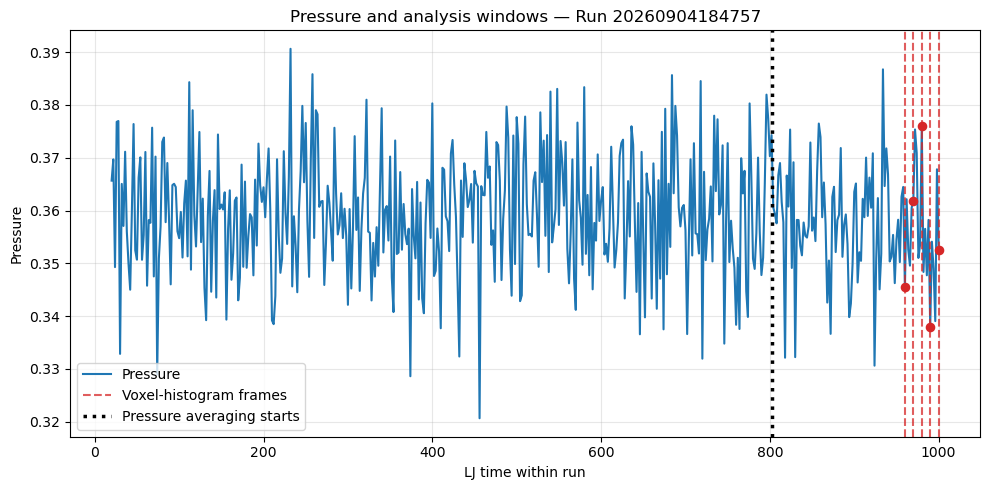

In [5]:
import matplotlib.pyplot as plt

from md_Helpers import open_run
from md_Helpers.voxel_fit import phase_fit_frame_indices


# --------------------------------------------------
# Choose the run
# --------------------------------------------------
RUN_ID = "20260904184757"


run = open_run(RUN_ID)
logs = run.logs_dataframe()

# Frames used for the averaged voxel histogram:
# -1, -6, -11, -16, and -21 when available.
voxel_frame_ids = phase_fit_frame_indices(len(logs))
voxel_samples = logs.iloc[voxel_frame_ids]

# Locate the beginning of the SQL pressure-summary window.
summary_start_step = int(run.state_row["Summary_Start_Step"])
summary_start_rows = logs[logs["run_step"] >= summary_start_step]

if summary_start_rows.empty:
    raise ValueError(
        f"Summary_Start_Step {summary_start_step} was not found in the logs."
    )

summary_start_time = summary_start_rows.iloc[0]["this_lj_time"]

# Skip the first 10 plotted samples for fresh lattice runs.
plot_logs = logs.iloc[10:] if run.started_from_lattice else logs

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    plot_logs["this_lj_time"],
    plot_logs["pressure"],
    color="C0",
    linewidth=1.5,
    label="Pressure",
)

# Voxel-histogram sampling times.
for index, (frame_id, sample) in enumerate(
    zip(voxel_frame_ids, voxel_samples.itertuples())
):
    ax.axvline(
        sample.this_lj_time,
        color="C3",
        linestyle="--",
        alpha=0.75,
        label="Voxel-histogram frames" if index == 0 else None,
    )
    ax.scatter(
        sample.this_lj_time,
        sample.pressure,
        color="C3",
        s=35,
        zorder=3,
    )

# Beginning of pressure averaging.
ax.axvline(
    summary_start_time,
    color="black",
    linestyle=":",
    linewidth=2.5,
    label="Pressure averaging starts",
)

ax.set_xlabel("LJ time within run")
ax.set_ylabel("Pressure")
ax.set_title(f"Pressure and analysis windows — Run {RUN_ID}")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()